### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

(array([], dtype=float64), [])

<Figure size 300x100 with 0 Axes>

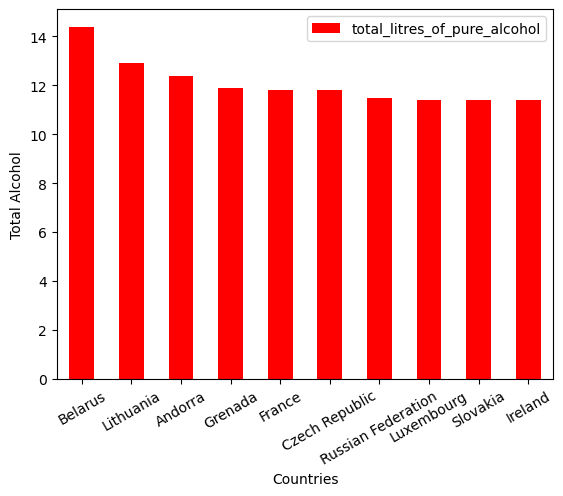

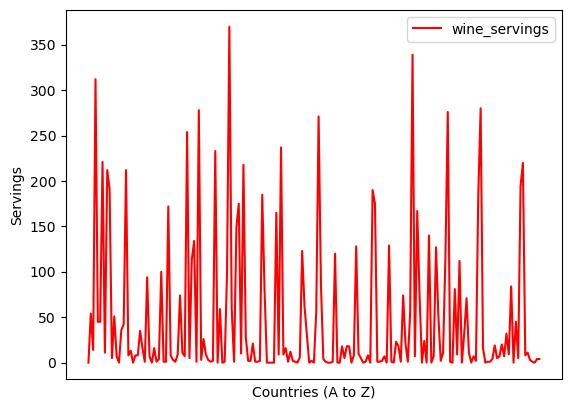

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df

#Uso la funzione sort_values e la funzione head per isolare e ordinare la colonna total... e prendo i primi dieci
top10 = df.sort_values(by="total_litres_of_pure_alcohol", ascending=False).head(10)
print(top10)

#Uso la funzione mean e per una lettura facilitata anche float ( così da non leggere float64 ) e round al second decimale
mean_beer_consumption = round(float(df["beer_servings"].mean()), 2)
print(mean_beer_consumption)
mean_wine_consumption = round(float(df["wine_servings"].mean()), 2)
print(mean_wine_consumption)
mean_spirit_consumption = round(float(df["spirit_servings"].mean()), 2)
print(mean_spirit_consumption)

#Posso utilizzare le operazioni di base nei dataframes, quindi creo la colonna alcohol_index e faccio le
#operazioni richieste, arrotondando al primo decimale
df["alcohol_index"] = round(((df["beer_servings"] + df["wine_servings"] + df["spirit_servings"]) / 3), 1)

#Come sopra faccio sort per ordinare la colonna e poi con head prendo il primo elemento
top_alcohol_index = df.sort_values(by="alcohol_index", ascending=False).head(1)
print(top_alcohol_index)

#Tramite l'operazione > 100 il dataframe di beer_consumption... contiene solo i valori della colonna beer_servings
#maggiori di 100 ( e quindi True )
beer_consumption_over_100 = df[df["beer_servings"] > 100]
print(beer_consumption_over_100)

plt.figure(figsize=(3,1))
top10.set_index("country").plot(kind="bar", y="total_litres_of_pure_alcohol", color="red")
plt.xlabel("Countries")
plt.ylabel("Total Alcohol")
plt.xticks(rotation=30) 

#Rimuovo il nome dei paesi dall'asse x ( non si possono visualizzare e non avrebbe neanche senso farlo )
wine_sorted = df.sort_values(by="country")
wine_sorted.set_index("country").plot(kind="line", y="wine_servings", xticks=[], color="red")
plt.xlabel("Countries (A to Z)")
plt.ylabel("Servings")
plt.xticks(rotation=45) 

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

job_country
Albania        79472.500000
Algeria        44550.000000
Argentina     105212.343750
Armenia        78757.000000
Australia     118987.574324
                  ...      
Uruguay        69333.333333
Uzbekistan     30750.000000
Vietnam        90927.236364
Zambia         90670.000000
Zimbabwe       67056.666667
Name: salary_year_avg, Length: 108, dtype: float64
job_country
Afghanistan      16
Albania         119
Algeria         111
Angola           11
Argentina      8736
               ... 
Venezuela        69
Vietnam        2414
Yemen            10
Zambia          104
Zimbabwe         81
Name: job_country, Length: 160, dtype: int64
job_country
Albania    157500.0
Name: salary_year_avg, dtype: float64
job_country
Albania    43200.0
Name: salary_year_avg, dtype: float64


Text(0, 0.5, 'Job sector')

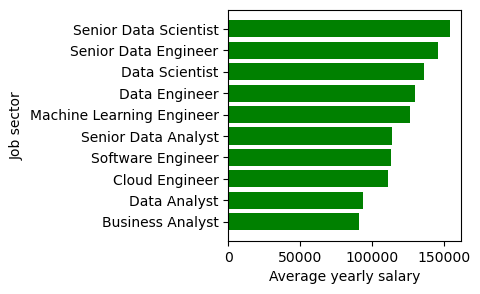

In [114]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

#Con la funzione mean calcolo la media. Utilizzo dropna per rimuovere i valori non presenti dal prodotto finale
average_salary_per_country = df.groupby("job_country")["salary_year_avg"].mean()
print(average_salary_per_country.dropna())

#Con la funzione count reitero job_country per controllare quante volte lo stesso viene inserito nel dataset
job_count_per_country = df.groupby("job_country")["job_country"].count()
print(job_count_per_country)

#Con max e dropna prendo il valore massimo degli stipendi, restituito da head con valore 1 ( ci interessa
#l'intervallo, di conseguenza solo l'estremo superiore e quello inferiore )
max_avg_salary_per_country = df.groupby("job_country")["salary_year_avg"].max()
max_avg_salary_per_country = max_avg_salary_per_country.dropna()
print(max_avg_salary_per_country.head(1))

#Riproduco la stessa cosa con min. Potrei utilizzare pure la funzione sort_values e il parametro ascending
min_avg_salary_per_country = df.groupby("job_country")["salary_year_avg"].min()
min_avg_salary_per_country = min_avg_salary_per_country.dropna()
print(min_avg_salary_per_country.head(1))

#Creo il grafico richiesto, raggruppando lo stipendio medio per gruppo di lavoro e facendone la media.
plt.figure(figsize=(3,3))
avg_salary_per_job_title = df.groupby("job_title_short")["salary_year_avg"].mean().sort_values(ascending=True)
plt.barh(avg_salary_per_job_title.index, avg_salary_per_job_title.values, color="green")
plt.xlabel("Average yearly salary")
plt.ylabel("Job sector")
plt.title("Average yearly salary per job sector")

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

day
Fri     17.15
Sat     20.44
Sun     21.41
Thur    17.68
Name: total_bill, dtype: float64
day
Fri     19
Sat     87
Sun     76
Thur    62
Name: day, dtype: int64
day
Fri     40.17
Sat     50.81
Sun     48.17
Thur    43.11
Name: total_bill, dtype: float64
day
Fri     5.75
Sat     3.07
Sun     7.25
Thur    7.51
Name: total_bill, dtype: float64
0       8.49
1       3.45
2       7.00
3      11.84
4       6.15
       ...  
239     9.68
240    13.59
241    11.34
242     8.91
243     9.39
Name: bill_per_person, Length: 244, dtype: float64
Sun


Text(0.5, 1.0, 'Mean bill per day of the week')

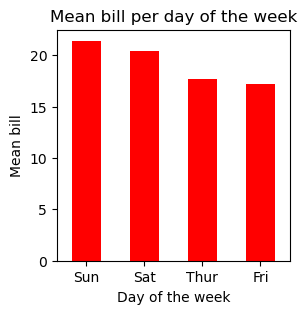

In [161]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df

#Faccio la media di ogni valore per giorno e arrotondo ( fino ai cents )
total_bill_mean_per_day = round(df.groupby("day")["total_bill"].mean(), 2)
print(total_bill_mean_per_day)

#Conto il numero di osservazioni per giorno
total_counts_per_day = df.groupby("day")["day"].count()
print(total_counts_per_day)

#Guardo il massimo per ogni giorno raggruppando e utilizzando la funzione max
max_total_bill = df.groupby("day")["total_bill"].max()
print(max_total_bill)

#Guardo il minimo per ogni giorno raggruppando e utilizzando la funzione min
min_total_bill = df.groupby("day")["total_bill"].min()
print(min_total_bill)

#Sfrutto le operazioni fra valori nei dataframe creando, per coerenza, la colonna conto per persona 
#rinominandola bill_per_person, essendo il df in inglese. Arrotondo ai cents
df["bill_per_person"] = round((df["total_bill"] / df["size"]), 2)
print(df["bill_per_person"])

#Utilizzo la funzione max sulla media per sapere quale giorno ha il conto medio più alto
total_bill_higer_day = total_bill_mean_per_day.max()
print(total_bill_higher_day)

plt.figure(figsize=(3,3))
sorted_total_bill = df.groupby("day")["total_bill"].mean()
sorted_total_bill.sort_values(ascending=False).plot(kind="bar", y="total_bill", color="red")
plt.xticks(rotation=0)
plt.xlabel("Day of the week")
plt.ylabel("Mean bill")
plt.title("Mean bill per day of the week")